In [ ]:
"""
This notebook is for roughly checking the dataset images for consistency and correctness.
"""

In [ ]:
import json
import os
import random
import matplotlib.pyplot as plt
import cv2
from Data_augmentation.utils.local_config import JSON_FILE_3DATASETS_FULL, BASE_FOLDER

In [2]:
# Load JSON and group by folder
with open(JSON_FILE_3DATASETS_FULL, 'r') as f:
    entries = [json.loads(line) for line in f]

folder_entries = {}
for entry in entries:
    folder = entry['folder']
    if folder not in folder_entries:
        folder_entries[folder] = []
    folder_entries[folder].append(entry)

print(f"Found {len(folder_entries)} unique folders:")
for folder, items in folder_entries.items():
    print(f"  {folder}: {len(items)} entries")

Found 3 unique folders:
  /hpc/group/youlab/ks723/storage/Exp_images/EmrahPaKp_dataset_renamed_AUG100_TrainValOnly: 33333 entries
  /hpc/group/youlab/ks723/storage/Exp_images/NL_evolution_library_Image_AUG100_TrainValOnly: 33333 entries
  /hpc/group/youlab/ks723/storage/Exp_images/Final_folder_uniform_fixedseed_100AUG: 33333 entries



Folder: /hpc/group/youlab/ks723/storage/Exp_images/EmrahPaKp_dataset_renamed_AUG100_TrainValOnly


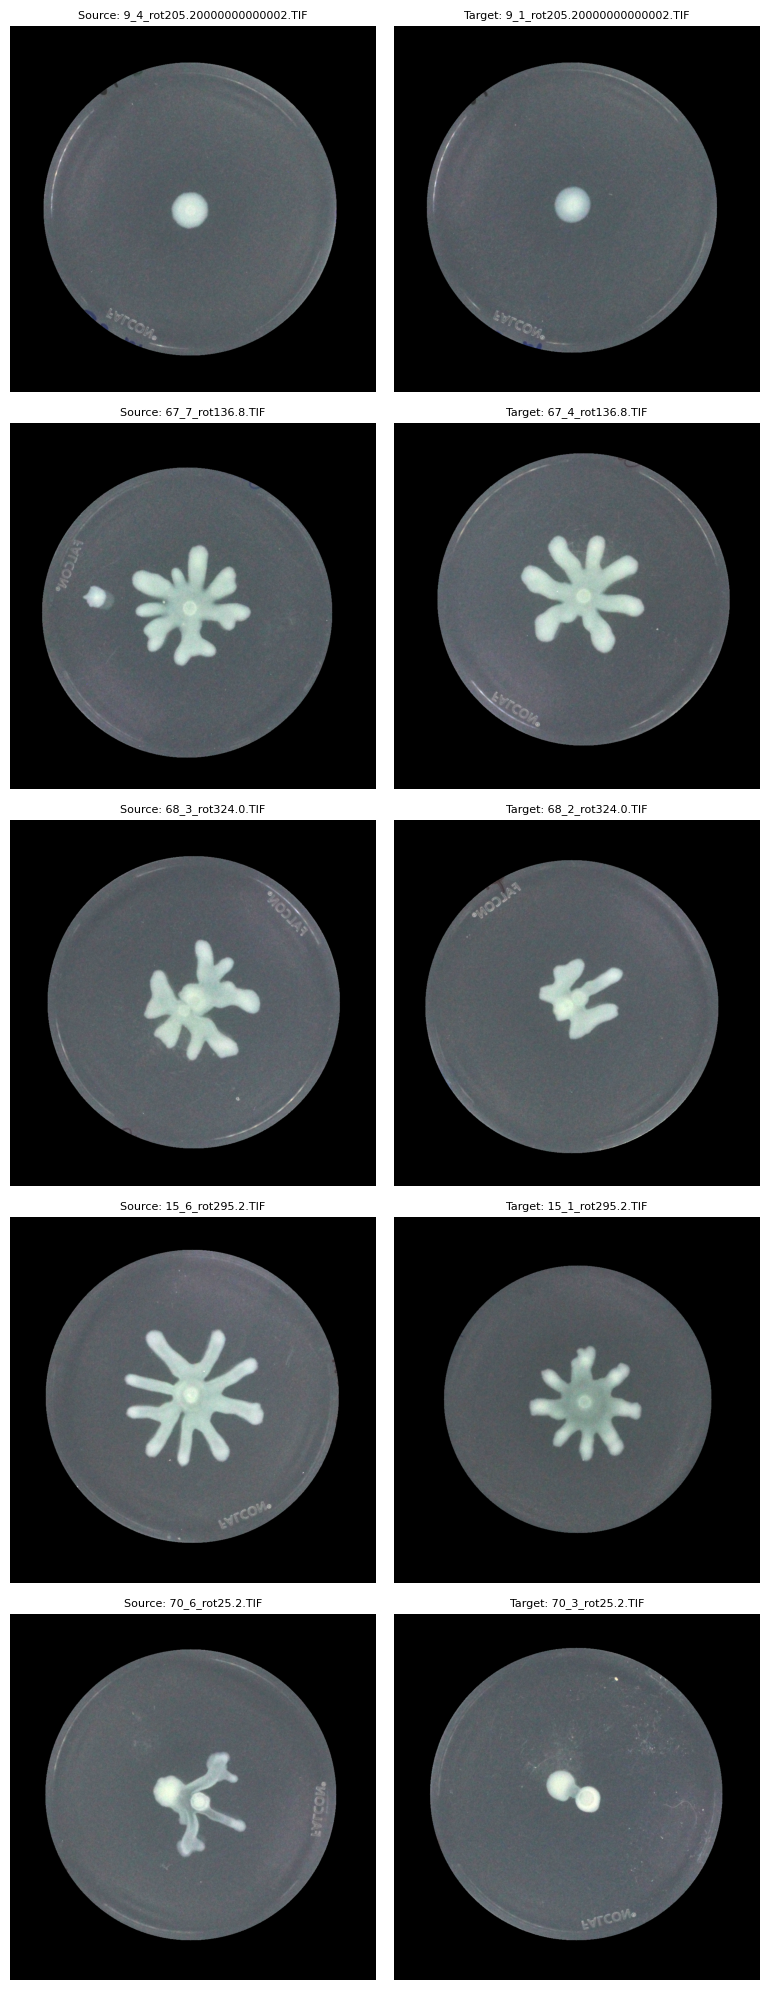


Folder: /hpc/group/youlab/ks723/storage/Exp_images/NL_evolution_library_Image_AUG100_TrainValOnly


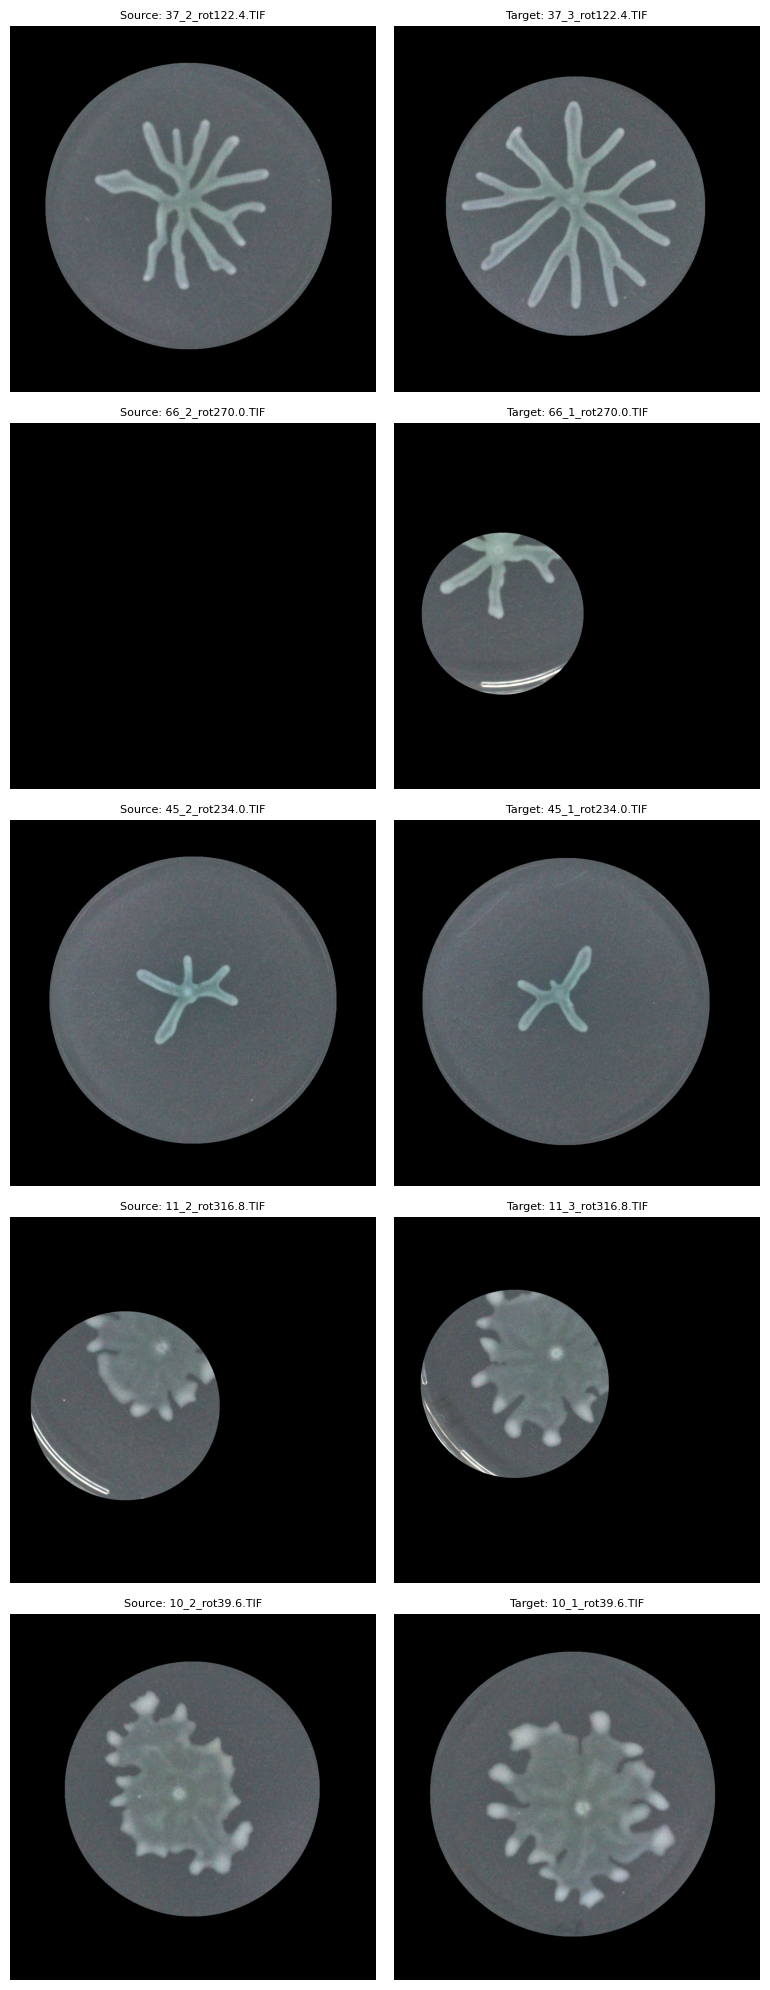


Folder: /hpc/group/youlab/ks723/storage/Exp_images/Final_folder_uniform_fixedseed_100AUG


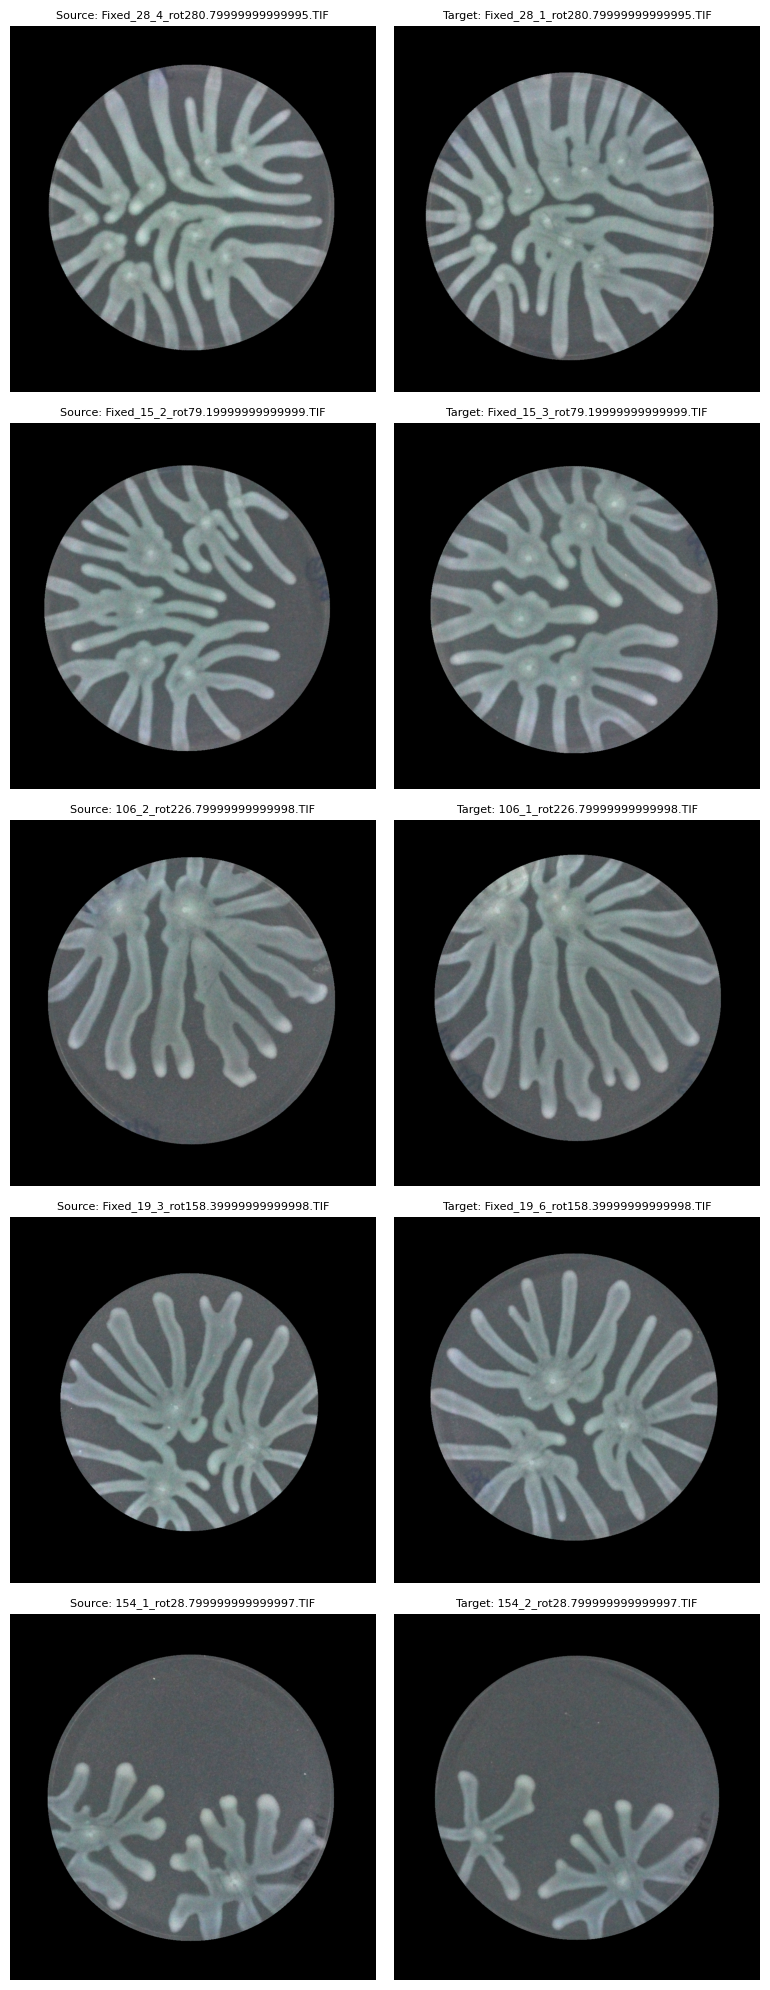

In [3]:
# Sample and display 5 images from each folder
random.seed(42)

for folder, items in folder_entries.items():
    print(f"\n{'='*80}")
    print(f"Folder: {folder}")
    print(f"{'='*80}")
    
    # Sample 5 random entries
    samples = random.sample(items, min(5, len(items)))
    
    fig, axes = plt.subplots(5, 2, figsize=(8, 20))
    
    for i, entry in enumerate(samples):
        source_path = os.path.join(entry['folder'], entry['source'])
        target_path = os.path.join(entry['folder'], entry['target'])
        
        # Read images (BGR -> RGB)
        source_img = cv2.imread(source_path)
        target_img = cv2.imread(target_path)
        
        if source_img is not None:
            source_img = cv2.cvtColor(source_img, cv2.COLOR_BGR2RGB)
        if target_img is not None:
            target_img = cv2.cvtColor(target_img, cv2.COLOR_BGR2RGB)
        
        # Display source
        axes[i, 0].imshow(source_img if source_img is not None else [[0]])
        axes[i, 0].set_title(f"Source: {entry['source']}", fontsize=8)
        axes[i, 0].axis('off')
        
        # Display target
        axes[i, 1].imshow(target_img if target_img is not None else [[0]])
        axes[i, 1].set_title(f"Target: {entry['target']}", fontsize=8)
        axes[i, 1].axis('off')
        
        # Check if images loaded
        if source_img is None:
            print(f"   Failed to load: {source_path}")
        if target_img is None:
            print(f"   Failed to load: {target_path}")
    
    plt.tight_layout()
    plt.show()

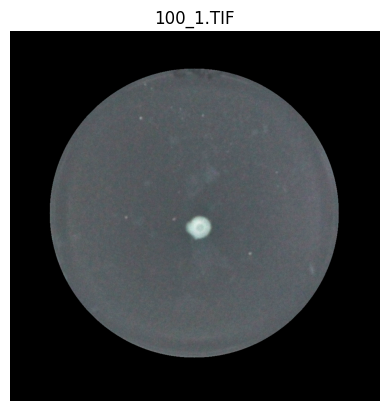

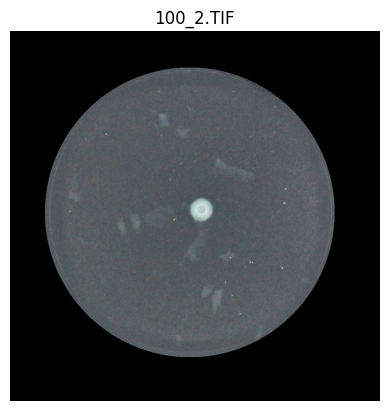

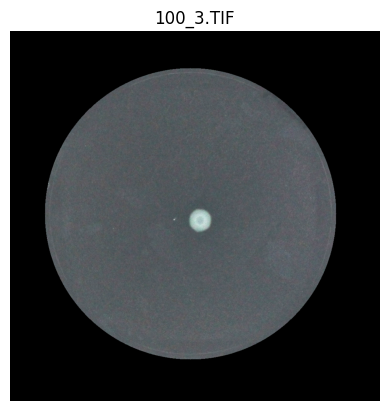

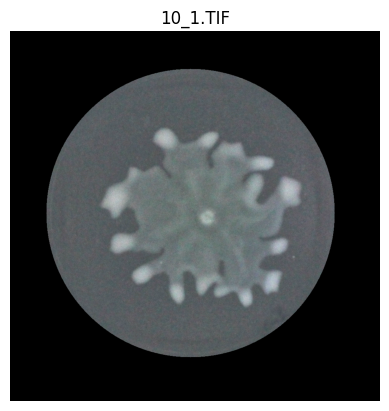

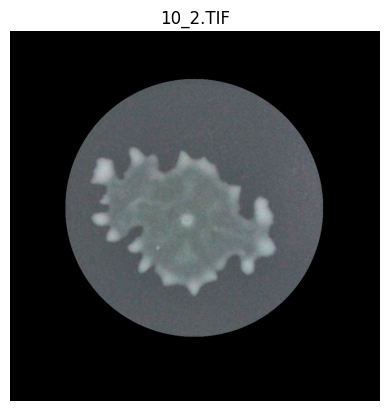

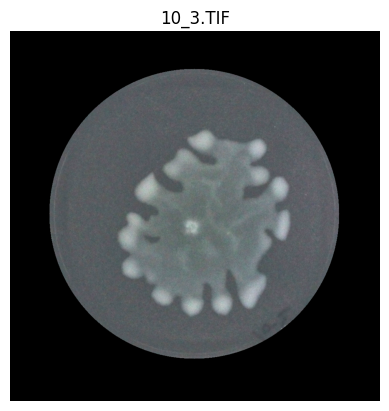

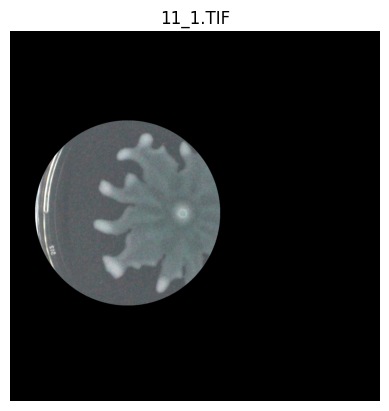

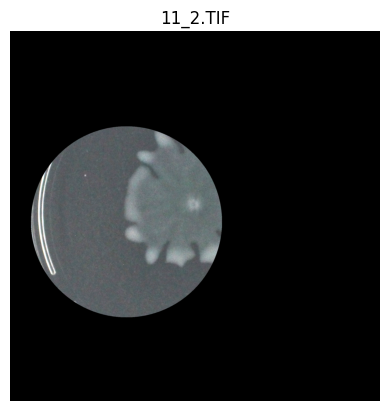

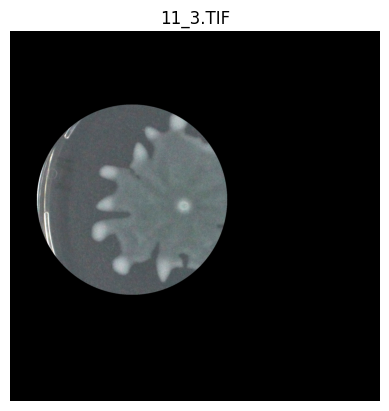

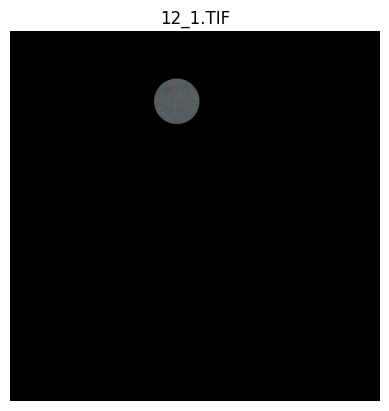

In [ ]:
# check images from non augmented dataset from Nan's data 

from Data_augmentation.utils.local_config import MUTANT_EXP_FOLDER_NOAUG

import os
import cv2 
import matplotlib.pyplot as plt
import random 
random.seed(42)

file_list = sorted(os.listdir(MUTANT_EXP_FOLDER_NOAUG))
# selected_files = random.sample(file_list, 10)
selected_files = file_list[:10]  # Select the first 10 files for consistency

for file in selected_files:
    file_path = os.path.join(MUTANT_EXP_FOLDER_NOAUG, file)
    img = cv2.imread(file_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.imshow(img)
    plt.title(file)
    plt.axis('off')
    plt.show()


In [ ]:
# check why the preprocess algorithm is going crazy 
import Data_augmentation.utils.shared_resources_config as shared_resources_config
import cv2 
import  numpy as np
from Data_augmentation.utils.local_config import MUTANT_EXP_FOLDER

def crop_experimental(img):
    """Optimized experimental image rotation using OpenCV warpAffine. Takes raw experimental images with plate boundaries 
    Steps:
    - detect plate circle with HoughCircles
    - mask and adjust contrast/brightness
    - re-apply circular mask and return
    """

    # similar code as some of the preprocessing functions
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Find edges in the image using Canny edge detection
    edges = cv2.Canny(img_gray, 100, 200)

    # Find circles in the image using HoughCircles method
    circles = cv2.HoughCircles(edges, cv2.HOUGH_GRADIENT, dp=1, minDist=20,
                               param1=50, param2=30, minRadius=20, maxRadius=600)
    
    circles_list = circles.tolist() if circles is not None else None

    if circles is not None:
        circles = np.round(circles[0, :]).astype("int")
        # Take the first circle found
        # Assuming first circle detected by Hough transform is the plate
        x_center, y_center, radius = circles[0]
        new_radius = radius - 82

        # Create a mask where all values are set to zero (black)
        mask = np.zeros((img.shape[0], img.shape[1]), dtype=np.uint8)
        cv2.circle(mask, (int(x_center), int(y_center)), int(new_radius), 255, -1)
        img_masked = cv2.bitwise_and(img, img, mask=mask)
        
        # Adjust contrast and brightness
        alpha = 1.5
        beta = 50
        adjusted_image = cv2.convertScaleAbs(img_masked, alpha=alpha, beta=beta)
        # no rotation here, just return cropped image
        output_img =cv2.bitwise_and(adjusted_image, adjusted_image, mask=mask)
    else:
        # no circle found -> return empty image of same shape
        output_img = np.zeros_like(img)

    return output_img, circles_list
 


filename= '11_1.TIF'
filepath = os.path.join(MUTANT_EXP_FOLDER, filename)

img_org= cv2.imread(filepath)
img_org= cv2.cvtColor(img_org, cv2.COLOR_BGR2RGB)

_, circles= crop_experimental(img_org)
print(circles)


filename_2= '1_1.TIF'
filepath = os.path.join(MUTANT_EXP_FOLDER, filename_2)

img_org= cv2.imread(filepath)
img_org= cv2.cvtColor(img_org, cv2.COLOR_BGR2RGB)

_, circles= crop_experimental(img_org)
print(circles)




[[[637.5, 995.5, 584.0], [646.5, 929.5, 588.4000244140625], [662.5, 904.5, 599.4000244140625], [655.5, 1010.5, 599.4000244140625], [609.5, 1040.5, 552.0], [641.5, 1104.5, 568.5999755859375], [661.5, 1099.5, 589.5], [643.5, 1029.5, 585.0999755859375], [623.5, 927.5, 565.2999877929688], [600.5, 946.5, 540.0], [616.5, 1061.5, 555.4000244140625], [655.5, 948.5, 599.4000244140625], [636.5, 895.5, 571.9000244140625], [612.5, 981.5, 558.7000122070312], [658.5, 1058.5, 597.2000122070312], [638.5, 1058.5, 577.4000244140625], [649.5, 977.5, 593.9000244140625], [706.5, 796.5, 599.4000244140625], [1008.5, 615.5, 582.9000244140625], [619.5, 1010.5, 565.2999877929688], [597.5, 1014.5, 543.2999877929688], [581.5, 1029.5, 525.7000122070312], [585.5, 909.5, 524.5999755859375], [545.5, 1014.5, 491.29998779296875], [631.5, 949.5, 570.7999877929688], [924.5, 1322.5, 599.4000244140625], [687.5, 827.5, 597.2000122070312], [583.5, 980.5, 530.0999755859375], [567.5, 1010.5, 513.5999755859375], [1343.5, 894.5,

In [ ]:
# Visualize the first detected circle on each problematic image
from Data_augmentation.utils.local_config import MUTANT_EXP_FOLDER
import cv2
import numpy as np
import matplotlib.pyplot as plt

def visualize_first_circle(img_path):
    """Detect circles and visualize the first one"""
    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    edges = cv2.Canny(img_gray, 100, 200)
    circles = cv2.HoughCircles(edges, cv2.HOUGH_GRADIENT, dp=1, minDist=20,
                               param1=50, param2=30, minRadius=20, maxRadius=600)
    
    # Draw first detected circle
    img_vis = img_rgb.copy()
    if circles is not None:
        circles = np.round(circles[0, :]).astype("int")
        x, y, r = circles[0]  # First circle
        cv2.circle(img_vis, (x, y), r, (255, 0, 0), 3)
        cv2.circle(img_vis, (x, y), 2, (255, 0, 0), 3)
        cv2.putText(img_vis, f"r={r}", (x-50, y-r-10), 
                   cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 0, 0), 2)
        return img_rgb, img_vis, r
    
    return img_rgb, img_vis, None

# Check manually specified problematic images
file_list = ['11_1.TIF', '12_1.TIF', '12_3.TIF','13_1.TIF','13_2.TIF','14_1.TIF']

for filename in file_list:
    filepath = os.path.join(MUTANT_EXP_FOLDER, filename)
    img_orig, img_vis, radius = visualize_first_circle(filepath)
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    axes[0].imshow(img_orig)
    axes[0].set_title(f"Original: {filename}")
    axes[0].axis('off')
    
    axes[1].imshow(img_vis)
    title = f"First Circle Detected (r={radius})" if radius else "No Circle Detected"
    axes[1].set_title(title)
    axes[1].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    if radius:
        print(f"{filename}: radius = {radius}")


Found 0 problem images out of 6 checked:
